# DS04 · Visual distributions, outliers, and robust summaries

<!-- paper-first -->
### Research question

**Reading:** [PD02](../../curriculum/papers/design.md#pd02). Review the assigned figure or result before starting the lesson.

**Question:** Could a mean conceal unstable effects, outliers, or a population mismatch?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes of guided work, plus 30–60 minutes in the assigned existing course material. **Prerequisite:** the foundations notebooks; follow this strand in order. The core exercise is synthetic, offline, and independently runnable. It demonstrates mechanics, not a validated participant-data analysis.

## Existing course material

Read [Data 8: Visualizing numerical distributions](https://github.com/data-8/textbook/blob/5235b7653f8dfaeb90e43419b9aa069322f2d60b/chapters/07/2/Visualizing_Numerical_Distributions.ipynb). Use the indicated topic, then return here to apply it to a neuroimaging question. Berkeley material is linked in its original form, not adapted or redistributed; its CC BY-NC-ND terms remain upstream. Neuromatch material is CC BY 4.0 with separately licensed software; selected unmodified copies live in `third_party/data_science`. The explanation and dataset below are original.

## Understand the transformation

A mean compresses a distribution to one number. Two groups can share the same mean while differing in spread, tails, or the mixture of sites they contain. A plot can reveal those differences, but its bins, limits, and omitted observations can also hide them. Begin with a histogram and individual observations, then state why the chosen summary matches the question.

Outliers are observations requiring explanation, not automatic deletion. A high regional-volume value could reflect a units error, a segmentation error, or a valid unusual person. The median is less sensitive to a single extreme value, but replacing a mean with a median changes the estimand. Robust summaries should therefore be a reasoned choice rather than a way to obtain the desired group difference.

This synthetic exercise makes one value extremely large. We compare mean, median, trimmed mean, and median absolute deviation before and after the change. These transformations lose different information: a median ignores the size of tail excursions, while trimming discards selected ranked observations. Neither operation identifies the source of a measurement error. In real imaging, use the scan and segmentation overlays as evidence, retain a QC log, and report sample counts by group or site. AI should help expose the effect of a rule, not choose exclusions by statistical significance.

## AI-guided prediction

First answer in your own words; then send this to Goose/Ollama or ChatGPT:

> Before plotting, ask me what a row and the measurement units mean. Compare mean, median and a declared trimmed mean with all observations visible. Explain which scientific target changes. Never remove the unusual value just because the mean shifts.

Use the model as a tutor and snippet writer. Require it to name the axes, units, fitting population, expected output, and one failure check. A code cell that runs is not proof that it answers the scientific question. Keep raw data unchanged and save your actual settings.

## Experiment

Change one of 101 near-normal values to 50. Plot both datasets on common limits. Predict which summary moves most; deliberately hide the extreme point with a narrow y-axis and explain the misleading display.

Run the following cells in order. Before each, predict what should remain unchanged and what should differ. The assertions test specific mathematical or bookkeeping properties, not clinical validity.

original mean -0.017945945665379208 median -0.06974197384419835 trimmed -0.049110365794761114
with unusual value mean 0.48785121551426364 median -0.04693846027785189 trimmed -0.01540064395537739


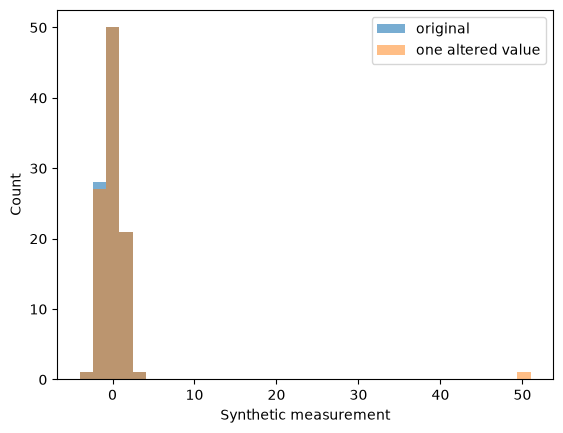

Original MAD: 0.8270778533457076


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import trim_mean, median_abs_deviation
rng = np.random.default_rng(304)
x = rng.normal(0,1,101); bad = x.copy(); bad[0] = 50
for label, data in [('original',x),('with unusual value',bad)]:
    print(label, 'mean',data.mean(),'median',np.median(data), 'trimmed',trim_mean(data,.1))
assert abs(bad.mean()-x.mean()) > abs(np.median(bad)-np.median(x))
fig,ax=plt.subplots(); ax.hist(x,bins=np.linspace(-4,51,35),alpha=.6,label='original')
ax.hist(bad,bins=np.linspace(-4,51,35),alpha=.5,label='one altered value')
ax.set(xlabel='Synthetic measurement',ylabel='Count'); ax.legend(); plt.show()
print('Original MAD:',median_abs_deviation(x))

## Explain, break, transfer

1. Save an input → operation → output diagram and state what information was lost.
2. Make the specified wrong choice above. Compare its result with the reference checks; explain why the misleading result is possible.
3. Work through the assigned upstream chapter's example using its own environment or hosted reader. Record one difference between its data and a participant/voxel/time-series dataset.
4. Ask the AI for a short application to a real imaging table, but do not run it until participant identifiers, units, missingness, and any training/test boundary are explicit. Never infer those properties from the column names alone.

**Evidence to submit:** one labeled result, the changed parameter, a failure diagnosis, and a five-sentence interpretation that separates a computational check from the research claim. Explain the result without looking at the model's wording.

<details><summary>Instructor check / answer guide</summary>

The mean should move much more than the median. A narrow plot can conceal the main data change. The example identifies sensitivity, not a justified real-data exclusion.

</details>

**Scope:** This local notebook and its numerical checks are part of the executable core. Completion of the external chapter is a learner assignment; its execution is not implied by the local result. No endorsement by the source authors or USC is implied.

### Return to the research question

Revisit [PD02](../../curriculum/papers/design.md#pd02) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
